In [2]:
# Imports and Libraries
import numpy as np
import pandas as pd

# Audio Processing Libraries
## https://medium.com/@rijuldahiya/a-comprehensive-guide-to-audio-processing-with-librosa-in-python-a49276387a4b
import librosa
import librosa.display
from scipy import signal

# Import resampy (for an error that comes up later)
import sys
!{sys.executable} -m pip install resampy

# Deal with .pkl files
## https://docs.python.org/3/library/pickle.html
import pickle

# CNN
import torch
from fastai.data.block import DataBlock, TransformBlock, CategoryBlock
from fastai.data.transforms import RandomSplitter
from fastai.vision.all import *
import torch.nn as nn
import torch.nn.functional as F

In [3]:
%env KAGGLE_USERNAME=sophia4827
%env KAGGLE_KEY=ac334c3351a2af38b3f6b0ce9d9922a6

!kaggle datasets download vishnu0399/emergency-vehicle-siren-sounds
!unzip emergency-vehicle-siren-sounds.zip

env: KAGGLE_USERNAME=sophia4827
env: KAGGLE_KEY=ac334c3351a2af38b3f6b0ce9d9922a6
Dataset URL: https://www.kaggle.com/datasets/vishnu0399/emergency-vehicle-siren-sounds
License(s): other
 99% 280M/282M [00:00<00:00, 382MB/s]
100% 282M/282M [00:00<00:00, 347MB/s]
Archive:  emergency-vehicle-siren-sounds.zip
  inflating: sounds/ambulance/sample.py  
  inflating: sounds/ambulance/sound_1.png  
  inflating: sounds/ambulance/sound_1.wav  
  inflating: sounds/ambulance/sound_10.png  
  inflating: sounds/ambulance/sound_10.wav  
  inflating: sounds/ambulance/sound_100.png  
  inflating: sounds/ambulance/sound_100.wav  
  inflating: sounds/ambulance/sound_101.png  
  inflating: sounds/ambulance/sound_101.wav  
  inflating: sounds/ambulance/sound_102.png  
  inflating: sounds/ambulance/sound_102.wav  
  inflating: sounds/ambulance/sound_103.png  
  inflating: sounds/ambulance/sound_103.wav  
  inflating: sounds/ambulance/sound_104.png  
  inflating: sounds/ambulance/sound_104.wav  
  inflating: 

In [4]:
# Mel-Frequency Cepstral Coefficients (MFCCs)
# MFCCs because it is common speech recognition tool
## essentially a way to represent the shape of a sound
## https://librosa.org/doc/latest/tutorial.html

def features_extractor(file_name):
  audio, sample_rate = librosa.load(file_name, res_type='kaiser_fast') # Loads the audio
  mfccs_features = librosa.feature.mfcc(y=audio, sr=sample_rate, n_mfcc=80) # Computes MFCCs
  mfccs_scaled_features = np.mean(mfccs_features.T, axis=0) # Averages them over time

  return mfccs_scaled_features # Returns an 80-dimensional NumPy array

In [5]:
audio_dataset_path = '/content/sounds/'

extracted_features = []
for path in os.listdir(audio_dataset_path): # Loops through each folder
    for file in os.listdir(audio_dataset_path+path+"/"): # Loops through all the files in the folder
        if file.lower().endswith(".wav"): # Looking for the ones that end in .wav (the audio file)
            file_name = audio_dataset_path+path+"/"+file # Full path
            data = features_extractor(file_name)
            extracted_features.append([data, path]) # data = feature, path = class

In [6]:
sound_df = pd.DataFrame(extracted_features,columns=['feature','class'])
sound_df.head()

,feature,class
0,"[-187.49748, 104.644165, -62.594807, -22.622454, -8.714674, -4.8508396, -9.419414, 12.427717, -7.018763, 10.184797, -4.9473114, -10.979335, -23.092693, -9.632925, -6.011667, -2.0389266, -2.3300858, -3.4367995, 3.6042688, 1.5941108, -7.1555157, -10.731414, -3.4463425, -1.6663595, -2.2137191, -1.478652, 0.6409392, 0.4789991, 1.6887811, 2.180244, -2.10392, -2.304247, 0.8984351, -1.5141734, 1.7368336, -1.0168461, -1.1339363, -0.9523983, 0.40352926, -1.4959828, -1.7619805, 0.0004230206, -1.3764232, -1.531604, 0.25579736, 0.71268386, 0.4172797, -0.101165935, -0.35575455, 0.20134418, -0.75317353,...",ambulance
1,"[-140.24297, 143.07497, -63.123123, -0.48639956, -29.631355, 16.597898, -4.716205, 4.336895, -29.375916, -3.0309496, -4.997046, 8.475223, -16.855263, -12.192577, -17.236034, 3.7984562, -2.1299613, 2.4327815, -9.6869545, -1.9780327, 2.3450139, 4.4068007, 0.9156362, -1.2982286, -8.272117, 2.9412043, -1.3979582, -1.6307664, -6.9217753, -3.5136926, -1.7976161, -2.9828708, -5.796076, -4.223276, -4.0193768, -1.8393223, -2.44691, -2.5112789, -1.266061, -1.2582068, 1.6590959, -0.87543833, -0.40647373, -1.9999733, 0.19788267, -0.41938752, 0.28054962, -2.4647415, -0.6078543, -2.3005, -1.4290651, -4....",ambulance
2,"[-254.05571, 112.549095, -49.834053, 3.5718753, -7.28982, 26.013536, 16.25789, 0.250011, -27.593262, -4.648859, 12.611686, 15.791917, -8.928306, -14.373268, -8.567932, 0.35859165, 4.9435344, -2.3494816, -11.698171, -3.7167141, 5.398817, -1.3275069, -1.9354433, -3.754282, -5.4643164, 0.36640283, 1.7044511, -4.7772737, -4.170113, -5.416353, 0.19195814, -1.51468, -5.225, -3.0104108, -2.351738, -3.2231345, -2.5031288, -3.1603534, -1.9791669, -0.9576489, -2.7900743, -3.2076774, -2.7209504, -2.965497, -1.1981366, -3.3316016, -1.9910032, -1.726003, -2.3109176, 0.07652237, -3.8264534, -4.824733, -...",ambulance
3,"[-424.1302, 107.87757, -64.31209, -4.623984, -13.297782, 35.873535, 47.935127, 7.419136, -36.64381, -8.333064, 44.490128, 24.101736, -28.77036, -4.979387, 18.539522, -0.71851116, 8.770181, -0.78196037, -16.923668, 18.108395, 13.151127, -19.051296, 0.58538103, 5.6440063, 0.5350756, 1.5299591, -2.6742775, 2.3423936, 2.7281766, 1.7138488, -1.8723346, -3.1097136, 5.0211, 2.0784833, -1.42565, 0.52532625, 1.0606699, 2.6017187, -0.9148799, -4.128104, 2.1703427, 0.26632386, -1.4309995, 0.90195394, -1.6314833, 2.2073162, 0.99097055, -0.5968692, 0.36197215, -1.9729413, 2.2094061, 2.1399765, -2.90736...",ambulance
4,"[-161.29358, 140.3027, -42.59801, 13.982895, -30.758604, 24.69365, 5.9378223, 28.68359, -2.389541, 0.6684722, -0.05281419, 5.788893, -2.7891443, -0.29435202, -8.756936, -1.2761449, -2.5427241, 2.5339637, -3.8390312, 1.2769494, -2.1253726, 0.26347598, -0.32570612, 0.5255803, -1.7645824, -1.3594563, 0.5262729, 2.2643309, -0.95264965, -2.5082064, -4.1540866, -0.63483936, -0.7699232, -4.4401503, -1.4080304, -4.0343833, -2.7752104, -2.6249788, -0.5070123, -2.1283154, -2.2869534, -2.8352425, -2.7463696, -4.1477976, 0.4474326, -2.6070058, -1.25338, -1.619247, -1.4474577, -3.5617192, -1.3807579, -...",ambulance


In [7]:
X = np.stack(sound_df['feature'].to_list()).astype('float32') # (n_samples, n_features)
y = sound_df['class'].to_list() # List of string labels
idxs = np.arange(len(X))

# Convert to a PyTorch float tensor
MFCCBlock = TransformBlock(type_tfms = lambda o: torch.tensor(o, dtype=torch.float32))

# Takes an index and returns the feature vector
def get_x(i): return X[i] # Numpy array
def get_y(i): return y[i] # String label

# Turns data into something a model can train on
sound = DataBlock(
    blocks=(MFCCBlock, CategoryBlock),
    get_items=lambda _: idxs, # Items are indices 0..N-1
    get_x=get_x,
    get_y=get_y,
    splitter=RandomSplitter(seed=42) # Splits training and validation
)

# Feeds data to your model in batches during training
sound_dls = sound.dataloaders(source=idxs, bs=256)


In [8]:
# Check what shape is coming from your DataLoaders
xb, yb = sound_dls.one_batch()
print("batch shape from dls:", xb.shape)  # should be [bs, 80]

batch shape from dls: torch.Size([256, 80])


In [9]:
n_classes = sound_dls.c  # number of labels

cnn = nn.Sequential(
    nn.Unflatten(1, (1, 80)),       # [bs, 80] -> [bs, 1, 80]
    nn.Conv1d(1, 16, kernel_size=3, padding=1),
    nn.BatchNorm1d(16),
    nn.ReLU(),
    nn.MaxPool1d(2),                # [bs, 16, 40]

    nn.Conv1d(16, 32, kernel_size=3, padding=1),
    nn.BatchNorm1d(32),
    nn.ReLU(),
    nn.MaxPool1d(2),                # [bs, 32, 20]

    nn.Conv1d(32, 64, kernel_size=3, padding=1),
    nn.BatchNorm1d(64),
    nn.ReLU(),
    nn.MaxPool1d(2),                # [bs, 64, 10]

    nn.AdaptiveAvgPool1d(1),        # [bs, 64, 1]
    nn.Flatten(),                   # [bs, 64]
    nn.Linear(64, n_classes)        # [bs, n_classes]
)

In [10]:
# learner
learn = Learner(sound_dls, cnn, loss_func=CrossEntropyLossFlat(), metrics=accuracy)

# training
learn.fit_one_cycle(100, 1e-3)

epoch,train_loss,valid_loss,accuracy,time
0,1.118491,1.117006,0.341667,00:00
1,1.115316,1.107586,0.333333,00:00
2,1.112806,1.102681,0.475000,00:00
3,1.110033,1.099591,0.483333,00:00
4,1.107032,1.097323,0.441667,00:00
5,1.104965,1.094936,0.383333,00:00
6,1.101807,1.092015,0.366667,00:00
7,1.098855,1.088327,0.341667,00:00
8,1.092985,1.083895,0.333333,00:00
9,1.087092,1.078601,0.350000,00:00


SuggestedLRs(valley=0.0020892962347716093)

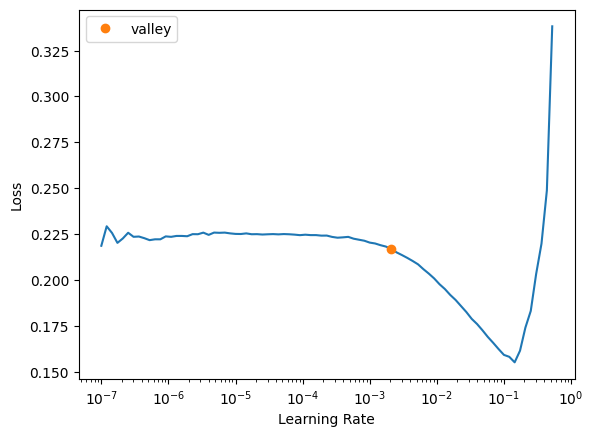

In [11]:
# Optimizing
learn.lr_find()

In [12]:
# Fine tune learner with better learning rate
learn.fine_tune(100, base_lr=0.004)

epoch,train_loss,valid_loss,accuracy,time
0,0.206856,0.228079,0.958333,00:00


epoch,train_loss,valid_loss,accuracy,time
0,0.215601,0.225588,0.958333,00:00
1,0.214419,0.221848,0.958333,00:00
2,0.210306,0.217915,0.958333,00:00
3,0.211359,0.216623,0.958333,00:00
4,0.213729,0.215227,0.958333,00:00
5,0.212093,0.214148,0.958333,00:00
6,0.210874,0.212258,0.958333,00:00
7,0.210848,0.210165,0.966667,00:00
8,0.210088,0.208235,0.966667,00:00
9,0.209841,0.206174,0.966667,00:00


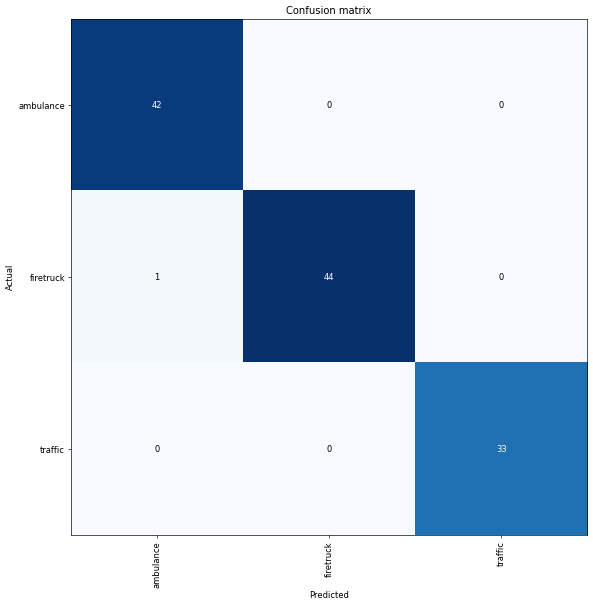

In [13]:
# Confusion matrix
interp = ClassificationInterpretation.from_learner(learn)
interp.plot_confusion_matrix(figsize=(10,10), dpi=60)

In [14]:
learn.summary()

Sequential (Input shape: 256 x 80)
Layer (type)         Output Shape         Param #    Trainable 
                     256 x 1 x 80        
Unflatten                                                      
____________________________________________________________________________
                     256 x 16 x 80       
Conv1d                                    64         True      
BatchNorm1d                               32         True      
ReLU                                                           
____________________________________________________________________________
                     256 x 16 x 40       
MaxPool1d                                                      
____________________________________________________________________________
                     256 x 32 x 40       
Conv1d                                    1568       True      
BatchNorm1d                               64         True      
ReLU                                                  